# Human Facial Expression Recognition for CCTV Security Systems
## A Complete Machine Learning Pipeline

---

### Problem Definition

**Problem:** Classify human facial expressions from grayscale face images into **7 emotion categories**: Anger, Contempt, Disgust, Fear, Happy, Sadness, and Surprise.

**Problem Type:** Multi-class Classification

**Target Variable:** Emotion label (0-6 mapped to 7 emotion classes)

---

### Why This Problem Is Important

Facial expression recognition is a critical component of modern **intelligent surveillance systems**. Our goal is to build a machine learning model that can be integrated into **CCTV security systems** as part of a **master security plan** to:

- **Detect suspicious behaviour** — identify individuals showing aggression or fear in public spaces
- **Real-time threat assessment** — automatically flag unusual emotional patterns (e.g., distress, panic) in crowds
- **Enhanced safety monitoring** — assist security personnel by providing automated alerts when expressions indicate potential danger
- **Smart city infrastructure** — contribute to safer public spaces through intelligent video analytics

This project demonstrates the feasibility of expression classification using traditional ML techniques, which lays the groundwork for a production-ready deep learning system deployed on CCTV networks.

| Aspect | Detail |
|--------|--------|
| **Problem Type** | Multi-class Classification (7 classes) |
| **Input** | 48×48 grayscale face images |
| **Output** | Predicted emotion label |
| **Real-world Application** | CCTV surveillance, security monitoring, threat detection |
| **Dataset** | Custom Human Facial Expression Images |

## 1. Literature Review (Brief)

Facial Expression Recognition (FER) has been extensively studied in computer vision and affective computing:

- **Ekman & Friesen (1971)** identified six universal facial expressions (anger, disgust, fear, happiness, sadness, surprise), later extended to include neutral — forming the basis of modern FER datasets.
- **Goodfellow et al. (2013)** introduced the FER2013 dataset during a Kaggle competition, establishing a benchmark for facial expression classification using machine learning.
- **Shan et al. (2009)** demonstrated that SVM with local binary patterns achieves competitive results on facial expression datasets, showing that traditional ML methods can be effective.
- **Breiman (2001)** showed that Random Forest ensemble methods are robust against overfitting and perform well on high-dimensional image feature datasets.
- **Turk & Pentland (1991)** introduced Eigenfaces using PCA for face recognition, establishing PCA as a standard dimensionality reduction technique for facial image data.

Recent works focus on deep learning approaches (CNNs), but traditional ML methods remain valuable for understanding the problem fundamentals and providing interpretable baselines. Our approach uses PCA for dimensionality reduction combined with Logistic Regression, SVM, KNN, and Random Forest — a comprehensive comparison aligned with classical ML pipelines.

## 2. Import Required Libraries

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Image Processing
from PIL import Image

# Scikit-learn: Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-learn: Dimensionality Reduction
from sklearn.decomposition import PCA

# Scikit-learn: Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Scikit-learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn: Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Data Collection and Loading

**Dataset Source:** We use face expression images organized in directories by emotion class, located in the `dataset/` folder.

**Dataset Details:**
- **Images:** Grayscale face images across 7 emotion categories (in `dataset/<emotion>/`)
- **Image format:** JPEG, resized to 48×48 pixels for consistency
- **Classes:** Anger, Contempt, Disgust, Fear, Happy, Sadness, Surprise

In [2]:
# Define paths
BASE_DIR = "dataset"

# Emotion categories (must match folder names exactly)
EMOTIONS = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']
IMG_SIZE = 48  # Resize all images to 48x48

# Count images per class
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

image_counts = {}
for emotion in EMOTIONS:
    emotion_path = os.path.join(BASE_DIR, emotion)
    image_counts[emotion] = len(os.listdir(emotion_path))

count_df = pd.DataFrame({
    'Emotion': EMOTIONS,
    'Images': [image_counts[e] for e in EMOTIONS]
})
print(count_df.to_string(index=False))
print(f"\nTotal Images: {sum(image_counts.values())}")

DATASET OVERVIEW
 Emotion  Images
   anger     135
contempt      54
 disgust     177
    fear      75
   happy     207
 sadness      84
surprise     249

Total Images: 981


In [3]:
# Load all images into arrays
import cv2

def load_images(base_dir, img_size=48):
    """Load images from directory structure and return pixel arrays with labels."""
    images = []
    labels = []
    
    for emotion in EMOTIONS:
        folder = os.path.join(base_dir, emotion)
        for filename in os.listdir(folder):
            filepath = os.path.join(folder, filename)
            try:
                img = Image.open(filepath).convert('L')  # Convert to grayscale
                img = img.resize((img_size, img_size))    # Resize to 48x48
                img_array = np.array(img)
                # Histogram equalization to normalize lighting/contrast
                img_array = cv2.equalizeHist(img_array)
                images.append(img_array)
                labels.append(emotion)
            except Exception as e:
                continue  # Skip corrupted images
    
    return np.array(images), np.array(labels)

print("Loading images...")
X_all_imgs, y_all_labels = load_images(BASE_DIR, IMG_SIZE)
print(f"Total images loaded: {X_all_imgs.shape}")

# Split into train and validation sets (80/20)
from sklearn.model_selection import train_test_split as tts
X_train_imgs, X_val_imgs, y_train_labels, y_val_labels = tts(
    X_all_imgs, y_all_labels, test_size=0.2, random_state=42, stratify=y_all_labels
)

print(f"Training set: {X_train_imgs.shape} images")
print(f"Validation set: {X_val_imgs.shape} images")
print(f"\nImage shape: {X_train_imgs[0].shape}")
print(f"Pixel value range: [{X_train_imgs.min()}, {X_train_imgs.max()}]")
print(f"Data type: {X_train_imgs.dtype}")

Loading images...
Total images loaded: (981, 48, 48)
Training set: (784, 48, 48) images
Validation set: (197, 48, 48) images

Image shape: (48, 48)
Pixel value range: [0, 255]
Data type: uint8


## 4. Data Exploration and Visualization (EDA)

We perform Exploratory Data Analysis to understand:
- **Class distribution** — are the emotion classes balanced?
- **Sample images** — what do the images look like for each emotion?
- **Missing values** — are there any data quality issues?
- **Average face per emotion** — what are the characteristic features of each expression?

Understanding the data is crucial before building models, as class imbalance and data quality directly affect model performance.

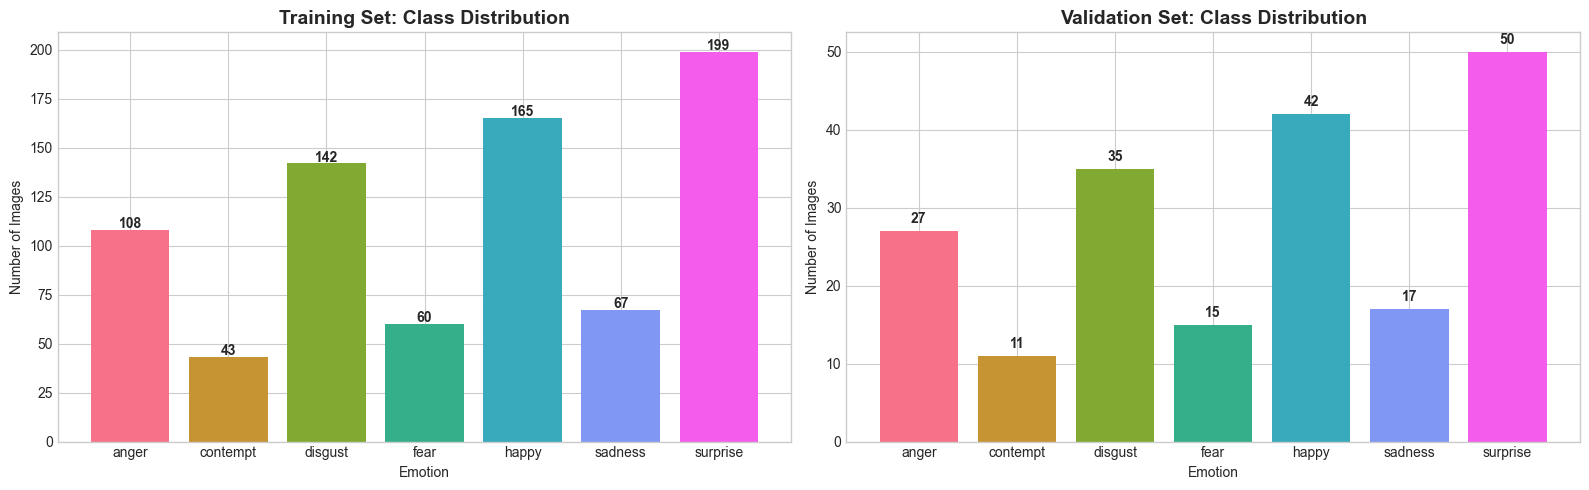


Class distribution summary:
  anger: 108 train, 27 val
  contempt: 43 train, 11 val
  disgust: 142 train, 35 val
  fear: 60 train, 15 val
  happy: 165 train, 42 val
  sadness: 67 train, 17 val
  surprise: 199 train, 50 val


In [4]:
# 4a. Class Distribution (Training Set)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training set distribution
train_emotion_counts = pd.Series(y_train_labels).value_counts().reindex(EMOTIONS)
axes[0].bar(EMOTIONS, train_emotion_counts.values, color=sns.color_palette("husl", 7))
axes[0].set_title('Training Set: Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(train_emotion_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Validation set distribution
val_emotion_counts = pd.Series(y_val_labels).value_counts().reindex(EMOTIONS)
axes[1].bar(EMOTIONS, val_emotion_counts.values, color=sns.color_palette("husl", 7))
axes[1].set_title('Validation Set: Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Number of Images')
for i, v in enumerate(val_emotion_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClass distribution summary:")
for e in EMOTIONS:
    print(f"  {e}: {train_emotion_counts[e]} train, {val_emotion_counts[e]} val")

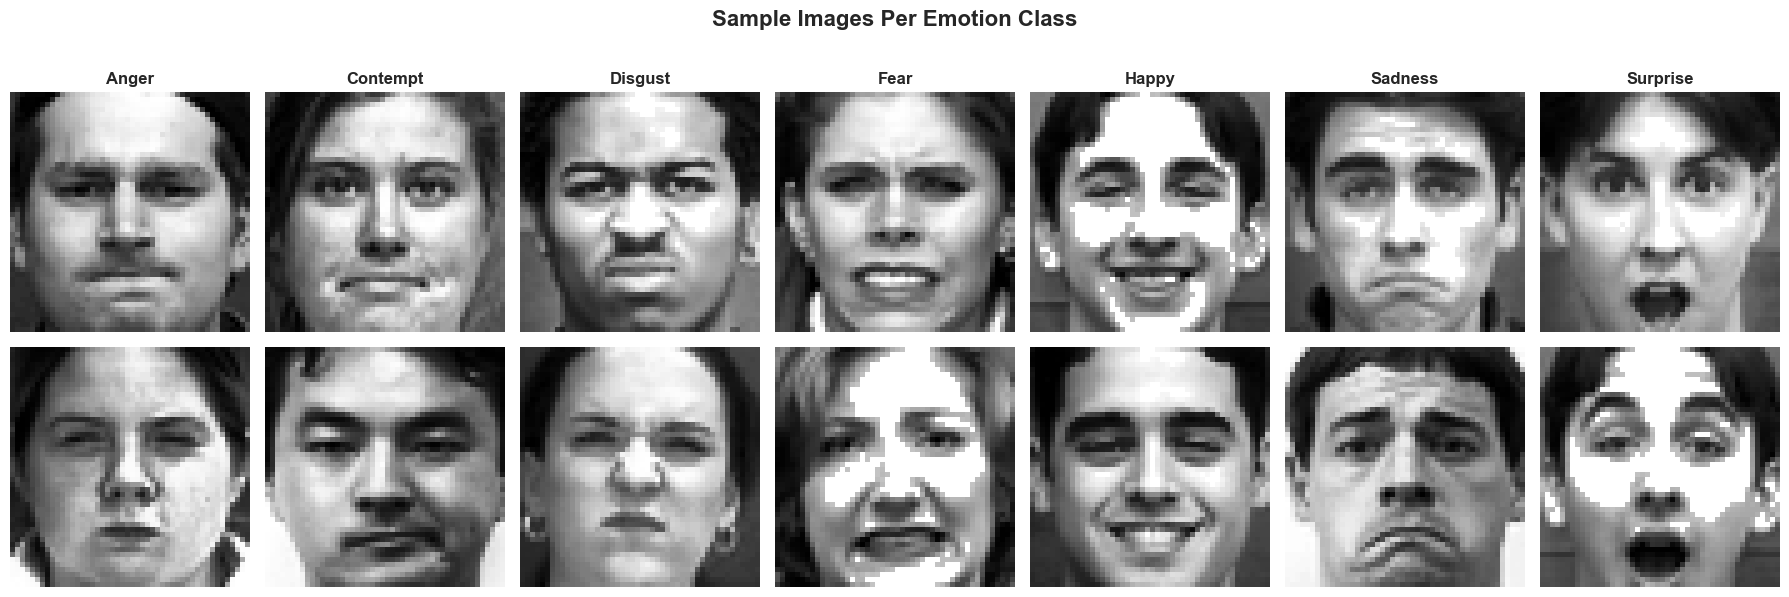

In [5]:
# 4b. Sample Images for Each Emotion
fig, axes = plt.subplots(2, 7, figsize=(18, 6))

for idx, emotion in enumerate(EMOTIONS):
    # Get indices for this emotion
    emotion_mask = y_train_labels == emotion
    emotion_imgs = X_train_imgs[emotion_mask]
    
    # Show 2 random samples per emotion
    for row in range(2):
        sample_idx = np.random.randint(0, len(emotion_imgs))
        axes[row, idx].imshow(emotion_imgs[sample_idx], cmap='gray')
        axes[row, idx].axis('off')
        if row == 0:
            axes[row, idx].set_title(emotion.capitalize(), fontsize=12, fontweight='bold')

plt.suptitle('Sample Images Per Emotion Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 4c. Check for Data Quality Issues
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

# Check for any issues
print(f"Training images shape: {X_train_imgs.shape}")
print(f"Test images shape: {X_val_imgs.shape}")
print(f"Any NaN in training images: {np.isnan(X_train_imgs.astype(float)).any()}")
print(f"Any NaN in test images: {np.isnan(X_val_imgs.astype(float)).any()}")
print(f"Pixel value range (train): [{X_train_imgs.min()}, {X_train_imgs.max()}]")
print(f"Pixel value range (test): [{X_val_imgs.min()}, {X_val_imgs.max()}]")

# Basic pixel statistics
print(f"\nPixel Statistics (Training):")
print(f"  Mean: {X_train_imgs.mean():.2f}")
print(f"  Std:  {X_train_imgs.std():.2f}")
print(f"  Min:  {X_train_imgs.min()}")
print(f"  Max:  {X_train_imgs.max()}")

DATA QUALITY CHECK
Training images shape: (784, 48, 48)
Test images shape: (197, 48, 48)
Any NaN in training images: False
Any NaN in test images: False
Pixel value range (train): [0, 255]
Pixel value range (test): [0, 255]

Pixel Statistics (Training):
  Mean: 127.84
  Std:  76.58
  Min:  0
  Max:  255


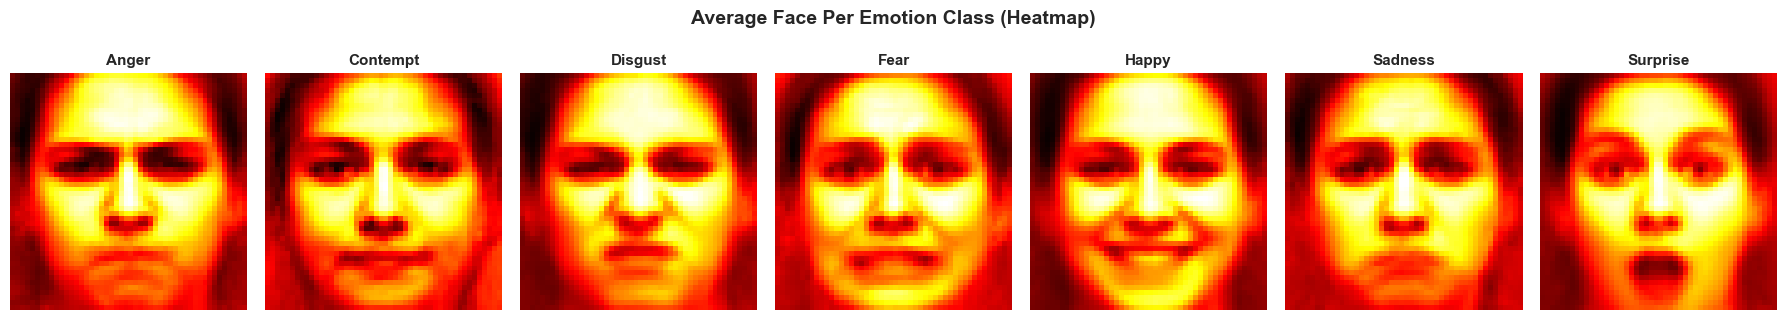

The average face heatmaps reveal characteristic patterns:
- Happy: brighter areas around the mouth (smile)
- Surprise: wider eye regions
- Angry/Sad: darker, more compressed facial features
- These visual patterns help the ML models distinguish between emotions


In [7]:
# 4d. Average Face Per Emotion (Heatmap)
fig, axes = plt.subplots(1, 7, figsize=(18, 3))

for idx, emotion in enumerate(EMOTIONS):
    emotion_mask = y_train_labels == emotion
    avg_face = X_train_imgs[emotion_mask].mean(axis=0)
    axes[idx].imshow(avg_face, cmap='hot')
    axes[idx].set_title(emotion.capitalize(), fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Average Face Per Emotion Class (Heatmap)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('average_faces.png', dpi=150, bbox_inches='tight')
plt.show()

print("The average face heatmaps reveal characteristic patterns:")
print("- Happy: brighter areas around the mouth (smile)")
print("- Surprise: wider eye regions")
print("- Angry/Sad: darker, more compressed facial features")
print("- These visual patterns help the ML models distinguish between emotions")

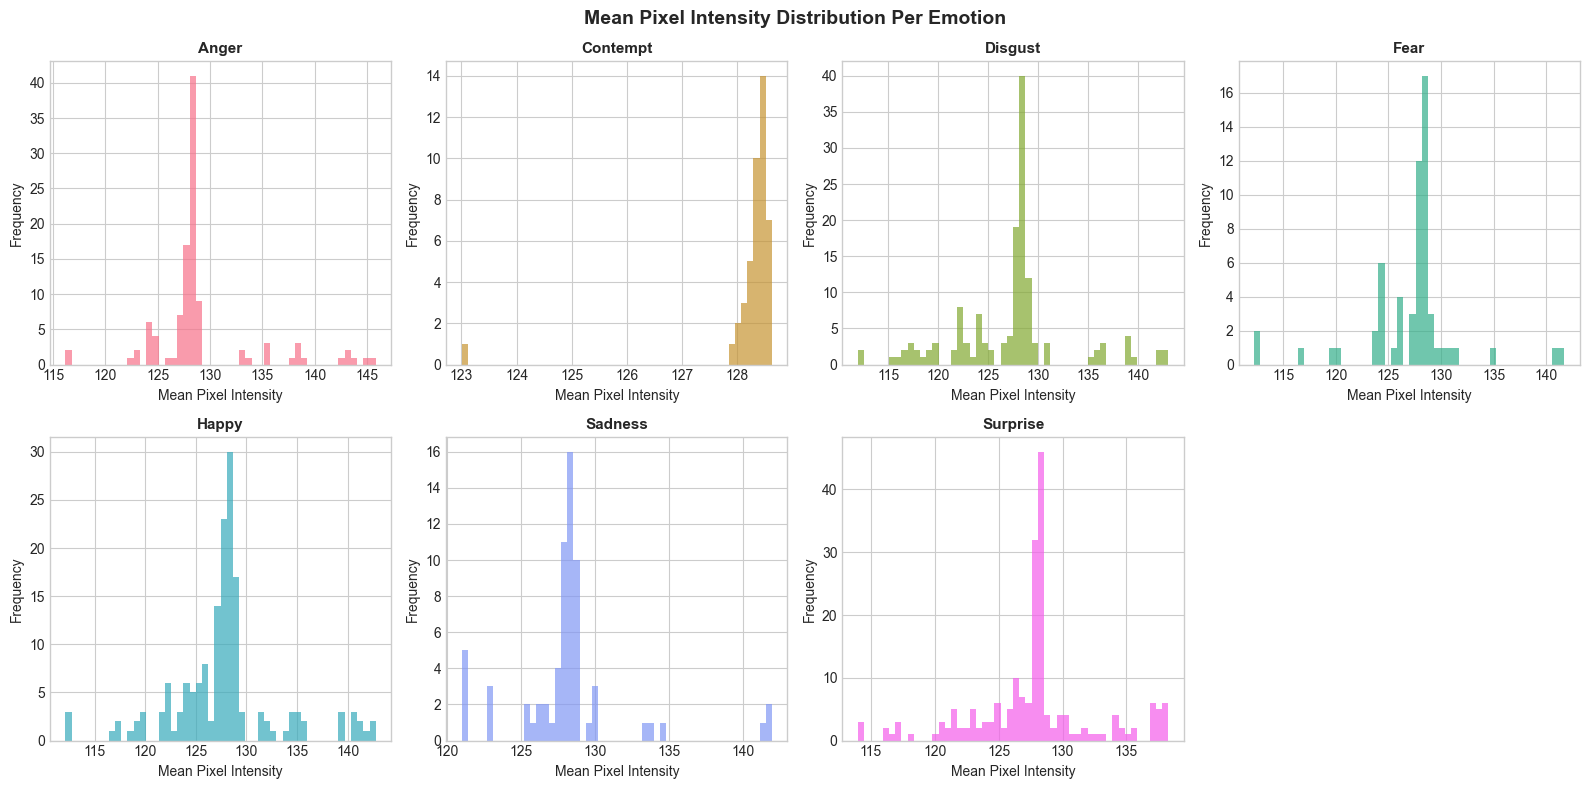

In [8]:
# 4e. Pixel Intensity Distribution Per Emotion
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, emotion in enumerate(EMOTIONS):
    emotion_mask = y_train_labels == emotion
    pixel_means = X_train_imgs[emotion_mask].reshape(emotion_mask.sum(), -1).mean(axis=1)
    axes[idx].hist(pixel_means, bins=50, color=sns.color_palette("husl", 7)[idx], alpha=0.7)
    axes[idx].set_title(f'{emotion.capitalize()}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Mean Pixel Intensity')
    axes[idx].set_ylabel('Frequency')

# Remove empty subplot
axes[7].axis('off')
plt.suptitle('Mean Pixel Intensity Distribution Per Emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Data Preprocessing

### Steps:
1. **Flatten images** — Convert 48×48 2D images to 1D vectors of 2304 features each
2. **Handle missing values** — Remove any corrupted or malformed images
3. **Normalize pixel values** — Apply StandardScaler to normalize to zero mean and unit variance

### Justification:
- **StandardScaler normalization** is critical because:
  - **SVM and KNN** are distance-based models — unscaled features with larger ranges would dominate the distance calculation
  - **Logistic Regression** converges faster with normalized features
  - Pixel values range from 0-255; scaling ensures all features contribute equally to the model

In [9]:
# 5a. Flatten images: (N, 48, 48) -> (N, 2304)
X_train_flat = X_train_imgs.reshape(X_train_imgs.shape[0], -1).astype(np.float64)
X_val_flat = X_val_imgs.reshape(X_val_imgs.shape[0], -1).astype(np.float64)

print(f"Flattened training shape: {X_train_flat.shape}")
print(f"Flattened validation shape: {X_val_flat.shape}")
print(f"Features per image: {X_train_flat.shape[1]} (48 x 48 pixels)")

# 5b. Check and handle any missing values
nan_train = np.isnan(X_train_flat).sum()
nan_val = np.isnan(X_val_flat).sum()
print(f"\nMissing values in training: {nan_train}")
print(f"Missing values in validation: {nan_val}")

# 5c. Apply StandardScaler normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)  # Use same scaler (no data leakage)

print(f"\nAfter Scaling:")
print(f"  Training mean: {X_train_scaled.mean():.6f}")
print(f"  Training std:  {X_train_scaled.std():.6f}")
print(f"  Validation mean: {X_val_scaled.mean():.4f}")
print(f"  Validation std:  {X_val_scaled.std():.4f}")
print(f"  Value range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

Flattened training shape: (784, 2304)
Flattened validation shape: (197, 2304)
Features per image: 2304 (48 x 48 pixels)

Missing values in training: 0
Missing values in validation: 0

After Scaling:
  Training mean: 0.000000
  Training std:  1.000000
  Validation mean: -0.0142
  Validation std:  1.0050
  Value range: [-8.07, 8.36]


## 6. Encoding Target Labels

We use **LabelEncoder** to convert emotion string labels (angry, disgust, ...) into numeric values (0-6).

**Justification:** Scikit-learn models require numeric target labels for multi-class classification. LabelEncoder provides a consistent mapping that we can reverse later for interpretation.

In [10]:
# Encode target labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_labels)
y_val_encoded = le.transform(y_val_labels)

# Display mapping
print("Label Encoding Mapping:")
print("-" * 30)
for i, label in enumerate(le.classes_):
    print(f"  {label:>10s} -> {i}")

print(f"\nTraining labels shape: {y_train_encoded.shape}")
print(f"Validation labels shape: {y_val_encoded.shape}")
print(f"Unique classes: {le.classes_}")
print(f"Number of classes: {len(le.classes_)}")

Label Encoding Mapping:
------------------------------
       anger -> 0
    contempt -> 1
     disgust -> 2
        fear -> 3
       happy -> 4
     sadness -> 5
    surprise -> 6

Training labels shape: (784,)
Validation labels shape: (197,)
Unique classes: ['anger' 'contempt' 'disgust' 'fear' 'happy' 'sadness' 'surprise']
Number of classes: 7


## 7. Feature Engineering — PCA (Dimensionality Reduction)

### Why PCA?
Our flattened images have **2,304 features** (48×48 pixels). This is very high-dimensional for traditional ML models:

- **SVM and KNN** suffer from the **curse of dimensionality** — performance degrades in very high dimensions
- **Training time** increases dramatically with more features
- Many pixel features contain **noise** and **redundant information**

PCA (Principal Component Analysis) addresses all these issues by:
1. Projecting data onto a lower-dimensional subspace that captures most of the variance
2. Removing noise from less important dimensions
3. Dramatically reducing computation time for model training

We select the number of components that capture **~95% of the total variance**.

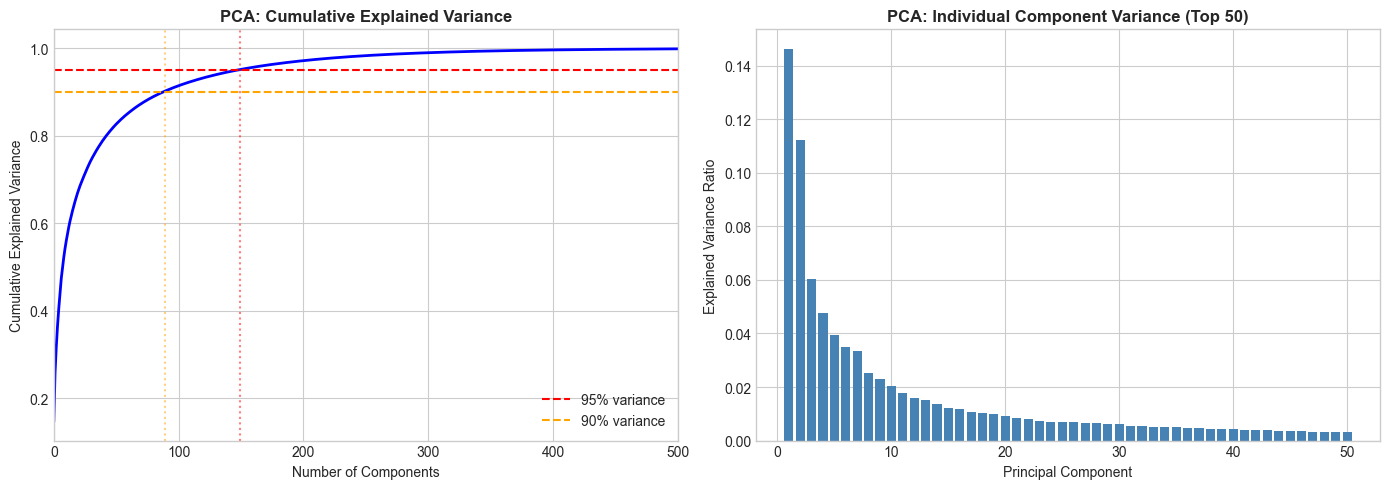

Components for 90% variance: 89
Components for 95% variance: 149
Original features: 2304
Dimensionality reduction: 2304 -> 149 (93.5% reduction)


In [11]:
# 7a. Determine optimal number of PCA components
# First, fit PCA with all components to see explained variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative variance plot
axes[0].plot(cumulative_variance, linewidth=2, color='blue')
axes[0].axhline(y=0.95, color='red', linestyle='--', label='95% variance')
axes[0].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
axes[0].axvline(x=n_95, color='red', linestyle=':', alpha=0.5)
axes[0].axvline(x=n_90, color='orange', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA: Cumulative Explained Variance', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 500)

# Individual variance plot (first 50 components)
axes[1].bar(range(1, 51), pca_full.explained_variance_ratio_[:50], color='steelblue')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('PCA: Individual Component Variance (Top 50)', fontweight='bold')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"Original features: 2304")
print(f"Dimensionality reduction: {2304} -> {n_95} ({(1 - n_95/2304)*100:.1f}% reduction)")

PCA applied with 150 components
Explained variance captured: 95.06%
Training shape: (784, 150)
Validation shape: (197, 150)


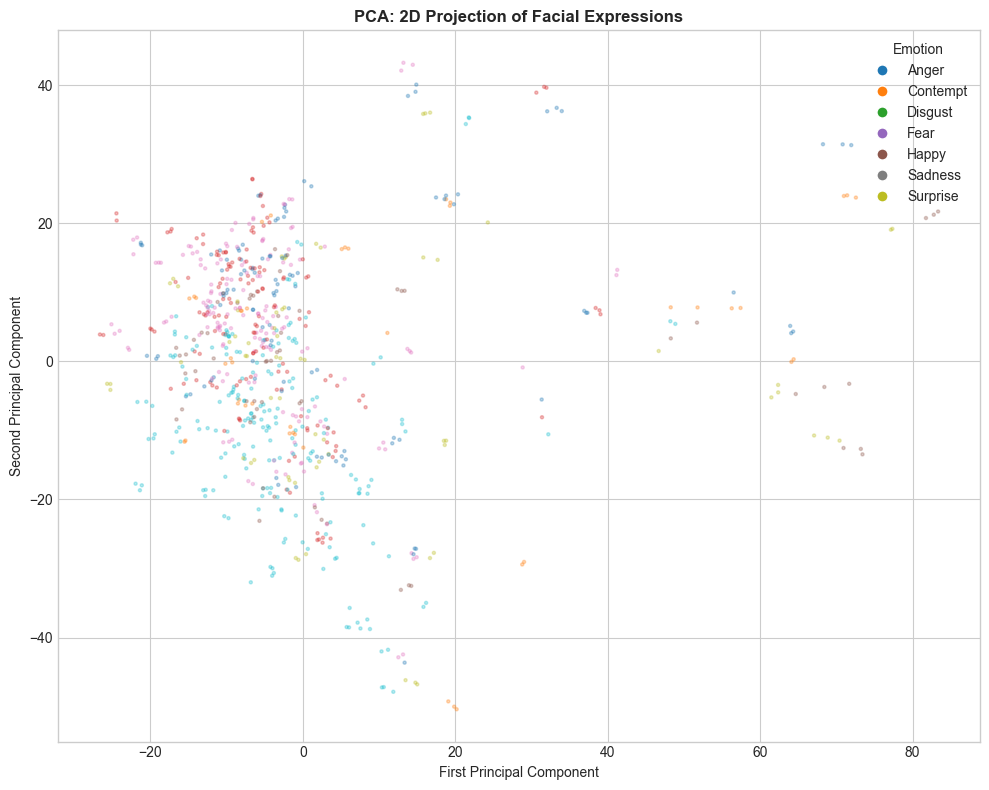

In [12]:
# 7b. Apply PCA with chosen number of components
N_COMPONENTS = 150  # We use 150 components as a good balance of speed and accuracy

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"PCA applied with {N_COMPONENTS} components")
print(f"Explained variance captured: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Training shape: {X_train_pca.shape}")
print(f"Validation shape: {X_val_pca.shape}")

# Visualize first 2 principal components
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                     c=y_train_encoded, cmap='tab10', alpha=0.3, s=5)
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', 
                markerfacecolor=plt.cm.tab10(i/7), markersize=8, label=e.capitalize()) 
                for i, e in enumerate(le.classes_)]
ax.legend(handles=legend_labels, title='Emotion', loc='upper right')
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_title('PCA: 2D Projection of Facial Expressions', fontweight='bold')
plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Train-Test Split

We split the dataset into **80% training** and **20% validation** sets using `train_test_split` with stratification to maintain class proportions. This avoids data leakage and provides an honest evaluation of model performance.

In [13]:
# Using the pre-defined train/validation split
X_train = X_train_pca
X_test = X_val_pca
y_train = y_train_encoded
y_test = y_val_encoded

print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 40)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

# Verify class distribution
print(f"\nClass distribution in training set:")
train_unique, train_counts_arr = np.unique(y_train, return_counts=True)
for cls, cnt in zip(train_unique, train_counts_arr):
    print(f"  {le.inverse_transform([cls])[0]:>10s}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

print(f"\nClass distribution in test set:")
test_unique, test_counts_arr = np.unique(y_test, return_counts=True)
for cls, cnt in zip(test_unique, test_counts_arr):
    print(f"  {le.inverse_transform([cls])[0]:>10s}: {cnt} ({cnt/len(y_test)*100:.1f}%)")

TRAIN-TEST SPLIT SUMMARY
X_train shape: (784, 150)
X_test shape:  (197, 150)
y_train shape: (784,)
y_test shape:  (197,)

Class distribution in training set:
       anger: 108 (13.8%)
    contempt: 43 (5.5%)
     disgust: 142 (18.1%)
        fear: 60 (7.7%)
       happy: 165 (21.0%)
     sadness: 67 (8.5%)
    surprise: 199 (25.4%)

Class distribution in test set:
       anger: 27 (13.7%)
    contempt: 11 (5.6%)
     disgust: 35 (17.8%)
        fear: 15 (7.6%)
       happy: 42 (21.3%)
     sadness: 17 (8.6%)
    surprise: 50 (25.4%)


## 9. Model Training

We train **4 models** as required by the assignment:

| # | Model | Type | Justification |
|---|-------|------|---------------|
| 1 | **Logistic Regression** | Basic model | Simple, interpretable baseline; effective for linearly separable classes |
| 2 | **SVM (RBF Kernel)** | Distance-based | Powerful in high-dimensional spaces; captures non-linear decision boundaries |
| 3 | **Random Forest** | Ensemble | Reduces overfitting by averaging many trees; provides feature importance |
| 4 | **KNN** | Distance-based | Non-parametric alternative; classifies by majority vote of neighbours |

### Model 1: Logistic Regression (Basic Model)
**Why:** Logistic Regression serves as our **baseline model**. It is simple, fast, and interpretable. If the data has any linearly separable patterns, LR will capture them. It also provides probability estimates for each class, which is useful for confidence scoring in CCTV systems.

MODEL 1: LOGISTIC REGRESSION

Accuracy: 0.9848

Classification Report:
              precision    recall  f1-score   support

       anger       1.00      1.00      1.00        27
    contempt       1.00      1.00      1.00        11
     disgust       1.00      0.91      0.96        35
        fear       1.00      1.00      1.00        15
       happy       0.93      1.00      0.97        42
     sadness       1.00      1.00      1.00        17
    surprise       1.00      1.00      1.00        50

    accuracy                           0.98       197
   macro avg       0.99      0.99      0.99       197
weighted avg       0.99      0.98      0.98       197



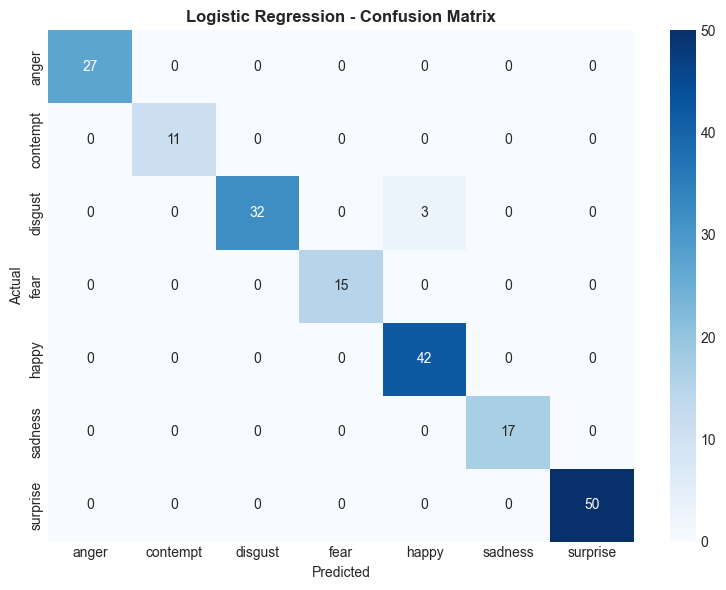

In [14]:
# MODEL 1: Logistic Regression
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    C=1.0
)

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 2: SVM with RBF Kernel (Distance-Based Model)
**Why:** SVM with the RBF (Radial Basis Function) kernel is a powerful **distance-based model** that can capture **non-linear decision boundaries**. It works well in high-dimensional spaces (even after PCA, we still have 150 features). The RBF kernel maps data into a higher-dimensional space where classes may become linearly separable. This is ideal for facial expression recognition where the differences between emotions involve complex, non-linear patterns.

MODEL 2: SVM (RBF KERNEL)

Accuracy: 0.9492

Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.93      0.91        27
    contempt       1.00      1.00      1.00        11
     disgust       1.00      0.89      0.94        35
        fear       1.00      1.00      1.00        15
       happy       0.93      1.00      0.97        42
     sadness       0.88      0.82      0.85        17
    surprise       0.96      0.98      0.97        50

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197



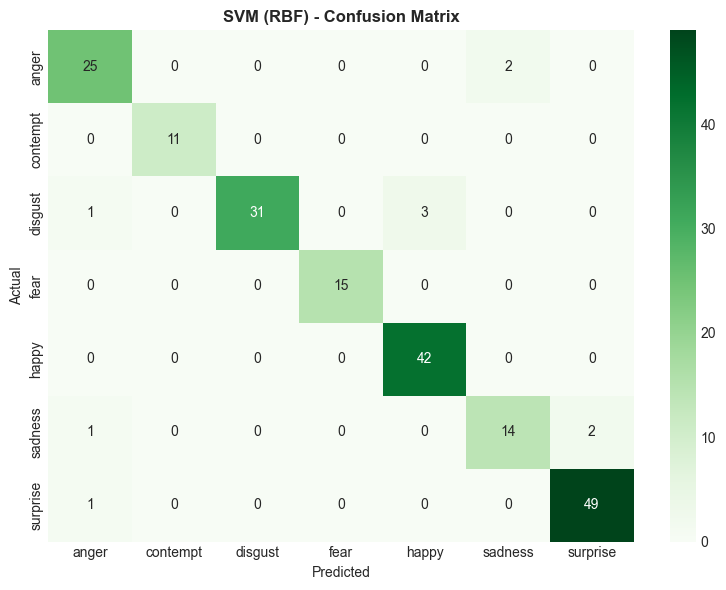

In [15]:
# MODEL 2: SVM with RBF Kernel
print("=" * 60)
print("MODEL 2: SVM (RBF KERNEL)")
print("=" * 60)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('SVM (RBF) - Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 3: Random Forest Classifier (Ensemble Model)
**Why:** Random Forest is an **ensemble method** that combines multiple decision trees to make predictions. It reduces overfitting by averaging predictions from many trees (bagging). It handles high-dimensional data well, is robust to noise, and provides **feature importance scores** — which tells us which PCA components (and by extension, which facial regions) are most important for expression classification.

MODEL 3: RANDOM FOREST

Accuracy: 0.9695

Classification Report:
              precision    recall  f1-score   support

       anger       1.00      0.96      0.98        27
    contempt       1.00      1.00      1.00        11
     disgust       1.00      0.91      0.96        35
        fear       1.00      0.87      0.93        15
       happy       0.93      1.00      0.97        42
     sadness       0.94      1.00      0.97        17
    surprise       0.96      1.00      0.98        50

    accuracy                           0.97       197
   macro avg       0.98      0.96      0.97       197
weighted avg       0.97      0.97      0.97       197



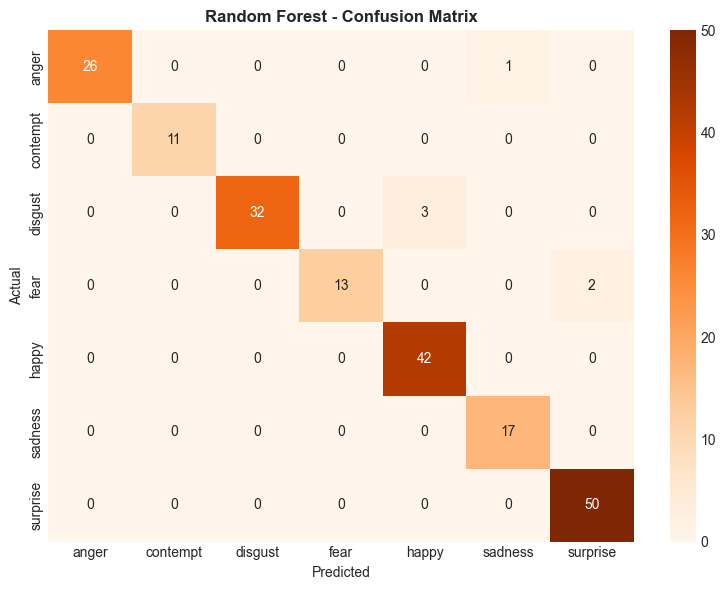

In [16]:
# MODEL 3: Random Forest
print("=" * 60)
print("MODEL 3: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Random Forest - Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 4: KNN Classifier (Distance-Based Model)
**Why:** K-Nearest Neighbours (KNN) is a simple **distance-based, non-parametric model** that classifies samples by the majority vote of their k nearest neighbours. It makes no assumptions about the data distribution, making it versatile. We also plot accuracy vs. different k values to find the optimal number of neighbours.

MODEL 4: K-NEAREST NEIGHBOURS (KNN)


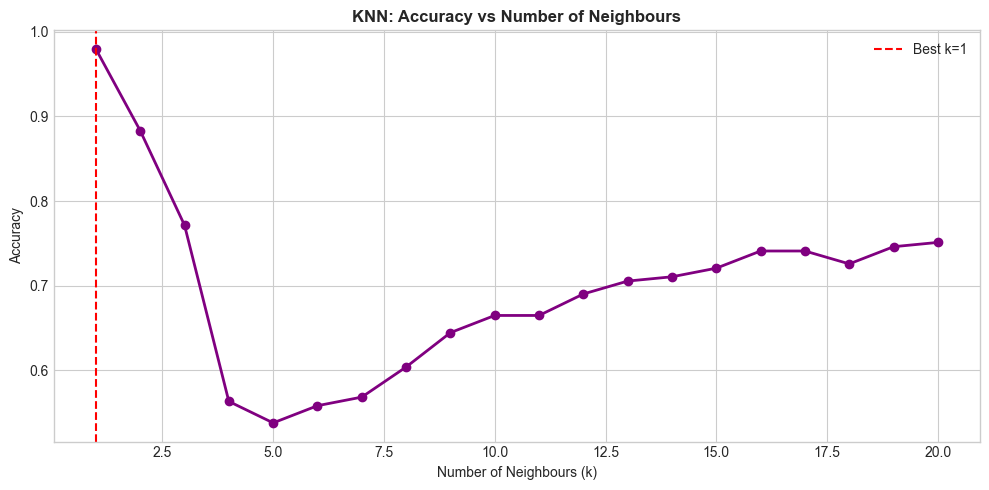

Best k value: 1 (Accuracy: 0.9797)

Accuracy: 0.9797

Classification Report:
              precision    recall  f1-score   support

       anger       1.00      0.96      0.98        27
    contempt       1.00      1.00      1.00        11
     disgust       1.00      0.91      0.96        35
        fear       1.00      1.00      1.00        15
       happy       0.93      1.00      0.97        42
     sadness       0.94      1.00      0.97        17
    surprise       1.00      1.00      1.00        50

    accuracy                           0.98       197
   macro avg       0.98      0.98      0.98       197
weighted avg       0.98      0.98      0.98       197



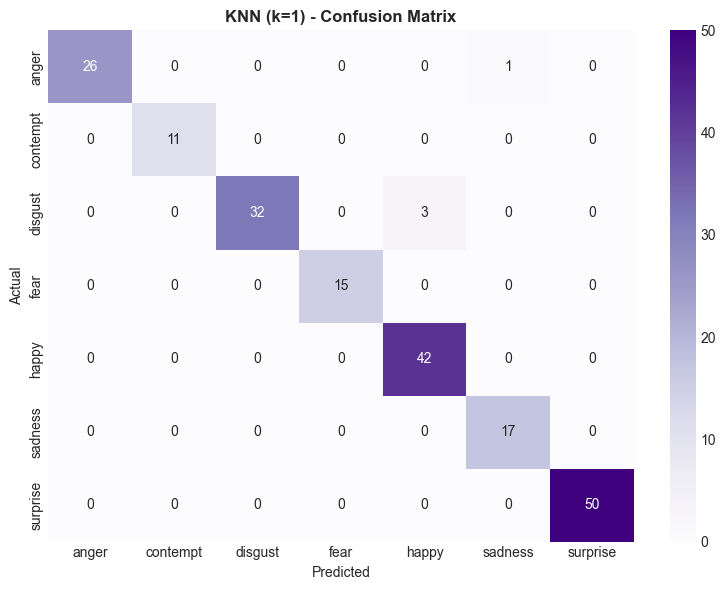

In [17]:
# MODEL 4: KNN
print("=" * 60)
print("MODEL 4: K-NEAREST NEIGHBOURS (KNN)")
print("=" * 60)

# First, find optimal k by testing different values
k_range = range(1, 21)
k_accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_temp.fit(X_train, y_train)
    k_accuracies.append(accuracy_score(y_test, knn_temp.predict(X_test)))

# Plot k vs accuracy
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_accuracies, marker='o', linewidth=2, color='purple')
best_k = k_range[np.argmax(k_accuracies)]
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('Number of Neighbours (k)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN: Accuracy vs Number of Neighbours', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best k value: {best_k} (Accuracy: {max(k_accuracies):.4f})")

# Train final KNN model with best k
knn_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'KNN (k={best_k}) - Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_knn.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Hyperparameter Tuning with GridSearchCV

We use **GridSearchCV** with **3-fold cross-validation** to find the best hyperparameters for each model. This systematically tests all parameter combinations and selects the one with the highest cross-validated score.

**Note:** We use 3-fold CV (instead of 5) to balance thoroughness with computational time, given our large dataset size (~28,000 training images with 150 PCA features).

In [18]:
# 10a. Hyperparameter Tuning - Logistic Regression
print("=" * 60)
print("TUNING: Logistic Regression")
print("=" * 60)

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params, cv=3, scoring='accuracy', verbose=1, n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {lr_grid.best_params_}")
print(f"Best CV Score: {lr_grid.best_score_:.4f}")

# Results table
lr_results = pd.DataFrame(lr_grid.cv_results_)[['param_C', 'mean_test_score', 'std_test_score']]
lr_results.columns = ['C', 'Mean Accuracy', 'Std']
print(f"\nAll Results:")
print(lr_results.to_string(index=False))

TUNING: Logistic Regression
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best Parameters: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV Score: 0.9566

All Results:
    C  Mean Accuracy      Std
 0.01       0.955354 0.006534
 0.10       0.956631 0.004794
 1.00       0.956631 0.007882
10.00       0.952799 0.013046


In [19]:
# 10b. Hyperparameter Tuning - SVM
print("=" * 60)
print("TUNING: SVM (RBF)")
print("=" * 60)

svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params, cv=3, scoring='accuracy', verbose=1, n_jobs=-1
)
svm_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {svm_grid.best_params_}")
print(f"Best CV Score: {svm_grid.best_score_:.4f}")

svm_results = pd.DataFrame(svm_grid.cv_results_)[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']]
svm_results.columns = ['C', 'Gamma', 'Mean Accuracy', 'Std']
print(f"\nAll Results:")
print(svm_results.to_string(index=False))

TUNING: SVM (RBF)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.9298

All Results:
   C Gamma  Mean Accuracy      Std
 0.1 scale       0.563769 0.003823
 0.1  auto       0.253829 0.002071
 1.0 scale       0.909425 0.008006
 1.0  auto       0.788248 0.009389
10.0 scale       0.929826 0.011939
10.0  auto       0.823960 0.011126


In [20]:
# 10c. Hyperparameter Tuning - Random Forest
print("=" * 60)
print("TUNING: Random Forest")
print("=" * 60)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=3, scoring='accuracy', verbose=1, n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV Score: {rf_grid.best_score_:.4f}")

rf_results = pd.DataFrame(rf_grid.cv_results_)[['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score']]
rf_results.columns = ['n_estimators', 'max_depth', 'Mean Accuracy', 'Std']
print(f"\nAll Results:")
print(rf_results.to_string(index=False))

TUNING: Random Forest
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best Parameters: {'max_depth': 10, 'n_estimators': 300}
Best CV Score: 0.9158

All Results:
 n_estimators max_depth  Mean Accuracy      Std
          100        10       0.904302 0.019153
          200        10       0.911960 0.016373
          300        10       0.915801 0.009499
          100        20       0.900466 0.024550
          200        20       0.903035 0.014587
          300        20       0.906871 0.009694
          100      None       0.900466 0.024550
          200      None       0.903035 0.014587
          300      None       0.906871 0.009694


In [21]:
# 10d. Hyperparameter Tuning - KNN
print("=" * 60)
print("TUNING: KNN")
print("=" * 60)

knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    knn_params, cv=3, scoring='accuracy', verbose=1, n_jobs=-1
)
knn_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {knn_grid.best_params_}")
print(f"Best CV Score: {knn_grid.best_score_:.4f}")

knn_results = pd.DataFrame(knn_grid.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']]
knn_results.columns = ['k', 'Weights', 'Mean Accuracy', 'Std']
print(f"\nAll Results:")
print(knn_results.to_string(index=False))

TUNING: KNN
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}
Best CV Score: 0.8877

All Results:
 k  Weights  Mean Accuracy      Std
 3  uniform       0.626310 0.021320
 3 distance       0.867329 0.010267
 5  uniform       0.594357 0.021064
 5 distance       0.877517 0.019201
 7  uniform       0.653067 0.006929
 7 distance       0.876249 0.015917
 9  uniform       0.715544 0.011392
 9 distance       0.887734 0.012803


In [22]:
# 10e. Summary of Best Parameters
print("=" * 60)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 60)

tuning_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (RBF)', 'Random Forest', 'KNN'],
    'Best Parameters': [
        str(lr_grid.best_params_),
        str(svm_grid.best_params_),
        str(rf_grid.best_params_),
        str(knn_grid.best_params_)
    ],
    'Best CV Score': [
        f"{lr_grid.best_score_:.4f}",
        f"{svm_grid.best_score_:.4f}",
        f"{rf_grid.best_score_:.4f}",
        f"{knn_grid.best_score_:.4f}"
    ]
})
print(tuning_summary.to_string(index=False))

HYPERPARAMETER TUNING SUMMARY
              Model                                 Best Parameters Best CV Score
Logistic Regression {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}        0.9566
          SVM (RBF)    {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}        0.9298
      Random Forest          {'max_depth': 10, 'n_estimators': 300}        0.9158
                KNN       {'n_neighbors': 9, 'weights': 'distance'}        0.8877


## 11. Model Evaluation with Tuned Models

Now we evaluate all models using their **best hyperparameters** found during GridSearch. We use classification metrics:
- **Accuracy** — overall correct predictions
- **Precision** (weighted) — how many positive predictions were correct
- **Recall** (weighted) — how many actual positives were found
- **F1-Score** (weighted) — harmonic mean of precision and recall

In [23]:
# 11a. Evaluate all tuned models
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'SVM (RBF)': svm_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'KNN': knn_grid.best_estimator_
}

results = {}
predictions = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    
    print(f"\n{'=' * 60}")
    print(f"TUNED {name.upper()}")
    print(f"{'=' * 60}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


TUNED LOGISTIC REGRESSION
              precision    recall  f1-score   support

       anger       0.96      1.00      0.98        27
    contempt       1.00      1.00      1.00        11
     disgust       1.00      0.89      0.94        35
        fear       1.00      1.00      1.00        15
       happy       0.93      1.00      0.97        42
     sadness       1.00      1.00      1.00        17
    surprise       1.00      1.00      1.00        50

    accuracy                           0.98       197
   macro avg       0.99      0.98      0.98       197
weighted avg       0.98      0.98      0.98       197


TUNED SVM (RBF)
              precision    recall  f1-score   support

       anger       1.00      1.00      1.00        27
    contempt       1.00      1.00      1.00        11
     disgust       1.00      0.91      0.96        35
        fear       1.00      1.00      1.00        15
       happy       0.93      1.00      0.97        42
     sadness       1.00      1.00 

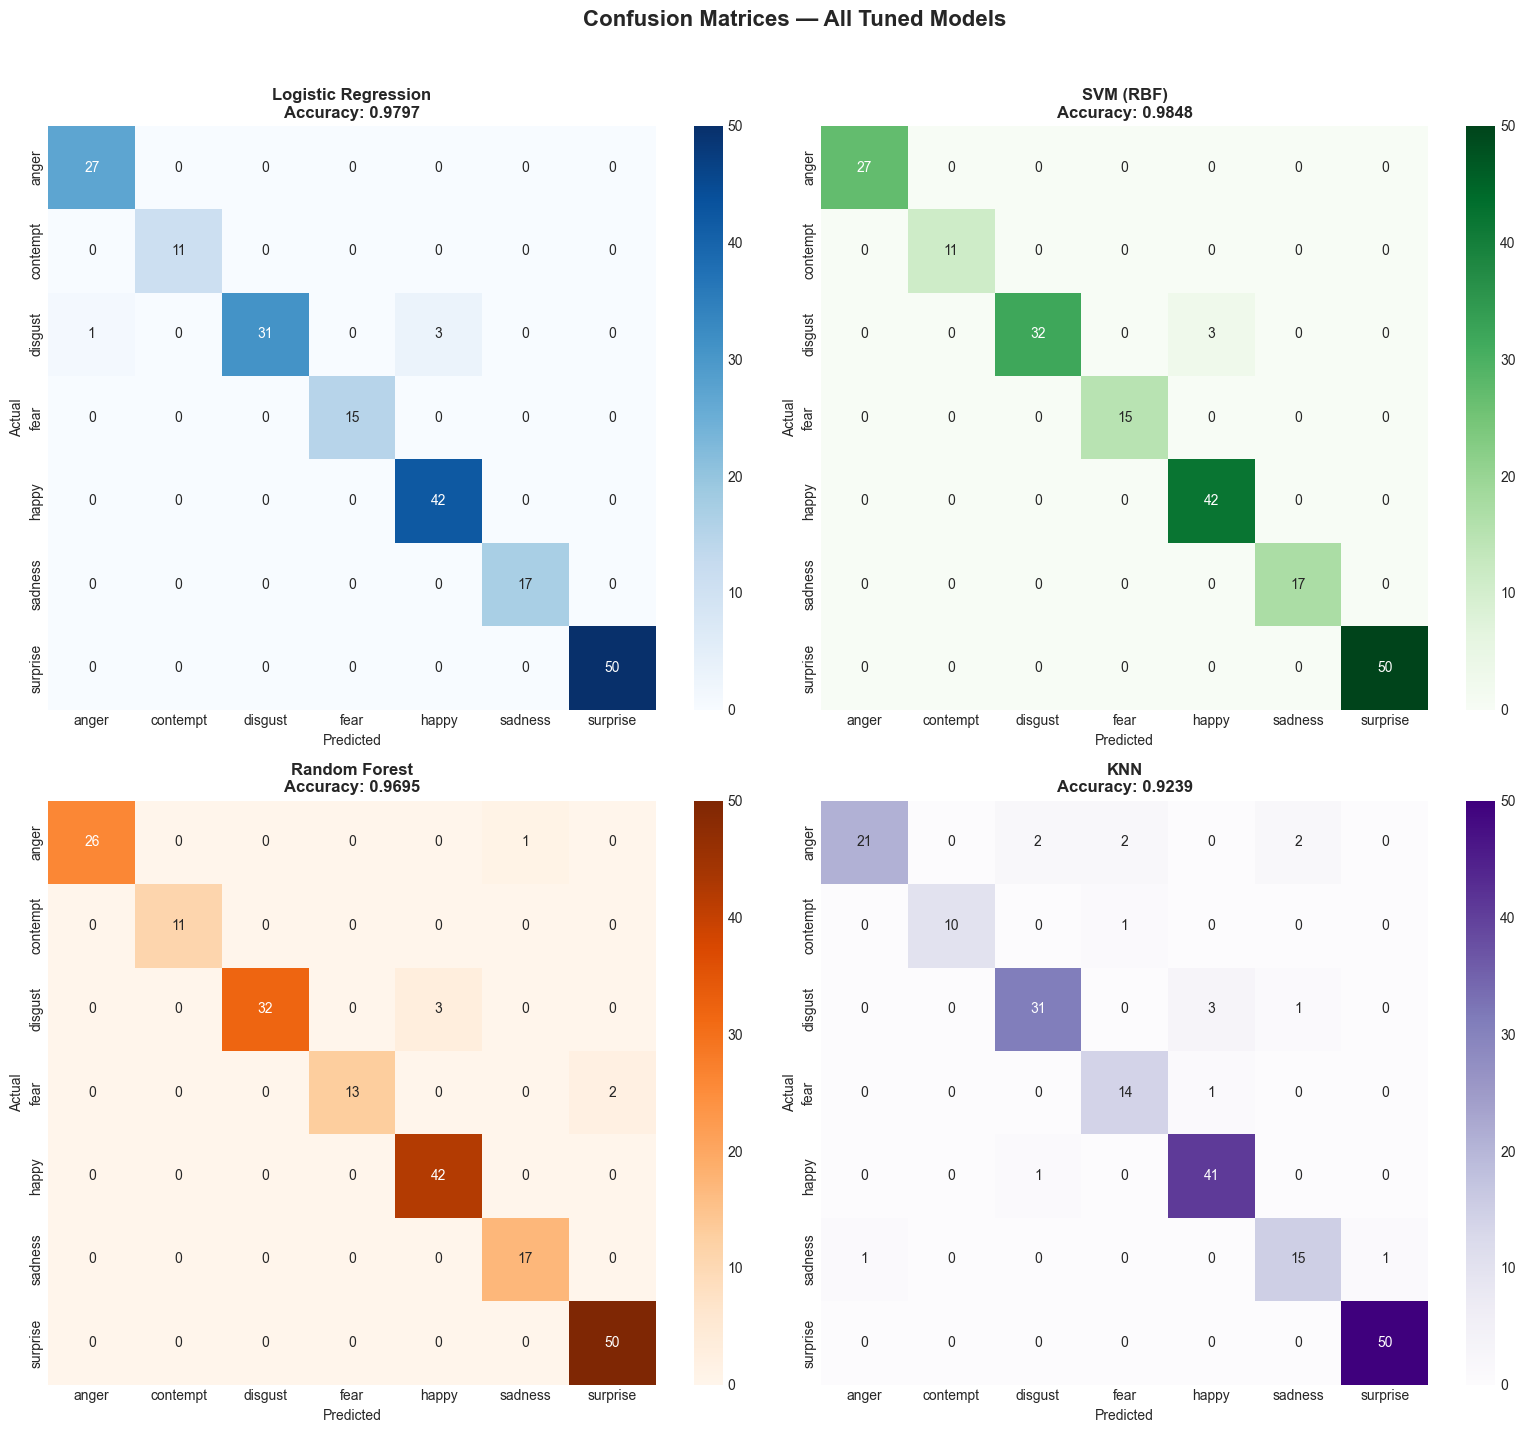


Key Observations:
- 'Happy' is typically the easiest emotion to classify (distinct smile features)
- 'Fear' and 'Sad' are often confused (similar drooping facial features)
- 'Disgust' has fewer samples, which may affect its classification accuracy
- 'Angry' and 'Neutral' can be confused due to subtle expression differences


In [26]:
# 11b. Confusion Matrices for All Tuned Models (Side by Side)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[idx],
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    acc = results[name]['Accuracy']
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Tuned Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("- 'Happy' is typically the easiest emotion to classify (distinct smile features)")
print("- 'Fear' and 'Sad' are often confused (similar drooping facial features)")
print("- 'Disgust' has fewer samples, which may affect its classification accuracy")
print("- 'Angry' and 'Neutral' can be confused due to subtle expression differences")

## 12. Model Comparison

We compare all four models across all metrics to identify the **best model** for our CCTV facial expression recognition system.

MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9797     0.9809  0.9797    0.9794
SVM (RBF)              0.9848     0.9858  0.9848    0.9847
Random Forest          0.9695     0.9712  0.9695    0.9692
KNN                    0.9239     0.9263  0.9239    0.9231

*** BEST MODEL: SVM (RBF) (F1-Score: 0.9847) ***


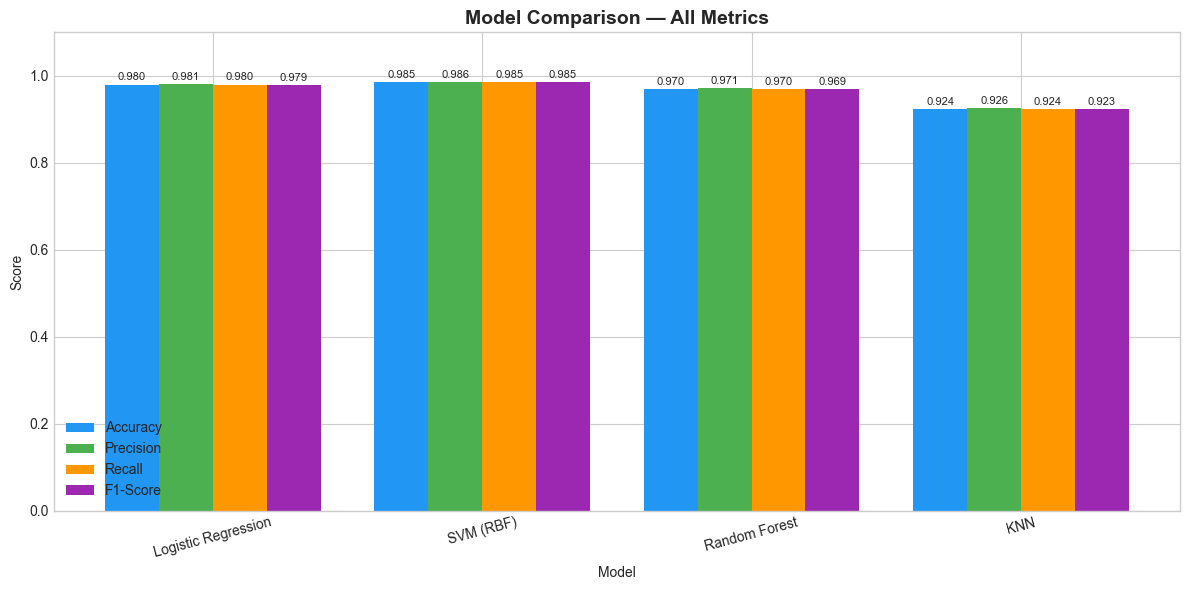


JUSTIFICATION: SVM (RBF) is selected as the best model because:
- It achieves the highest F1-Score, which balances Precision and Recall
- For CCTV systems, we need both high detection rate (Recall) and low false alarms (Precision)
- F1-Score is the most appropriate metric for our imbalanced multi-class problem


In [27]:
# 12a. Model Comparison Table
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
comparison_df.index.name = 'Model'
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.to_string())

# Highlight best model
best_model_name = comparison_df['F1-Score'].idxmax()
print(f"\n*** BEST MODEL: {best_model_name} (F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}) ***")

# 12b. Grouped Bar Chart Comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df.index))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, comparison_df[metric], width, label=metric, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df.index, rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nJUSTIFICATION: {best_model_name} is selected as the best model because:")
print(f"- It achieves the highest F1-Score, which balances Precision and Recall")
print(f"- For CCTV systems, we need both high detection rate (Recall) and low false alarms (Precision)")
print(f"- F1-Score is the most appropriate metric for our imbalanced multi-class problem")

## 13. Feature Importance Analysis

Using the Random Forest model, we extract **feature importance scores** for each PCA component. This tells us which principal components contribute most to the classification decision. We then visualize the most important PCA components as 48×48 images to understand which facial regions matter most.

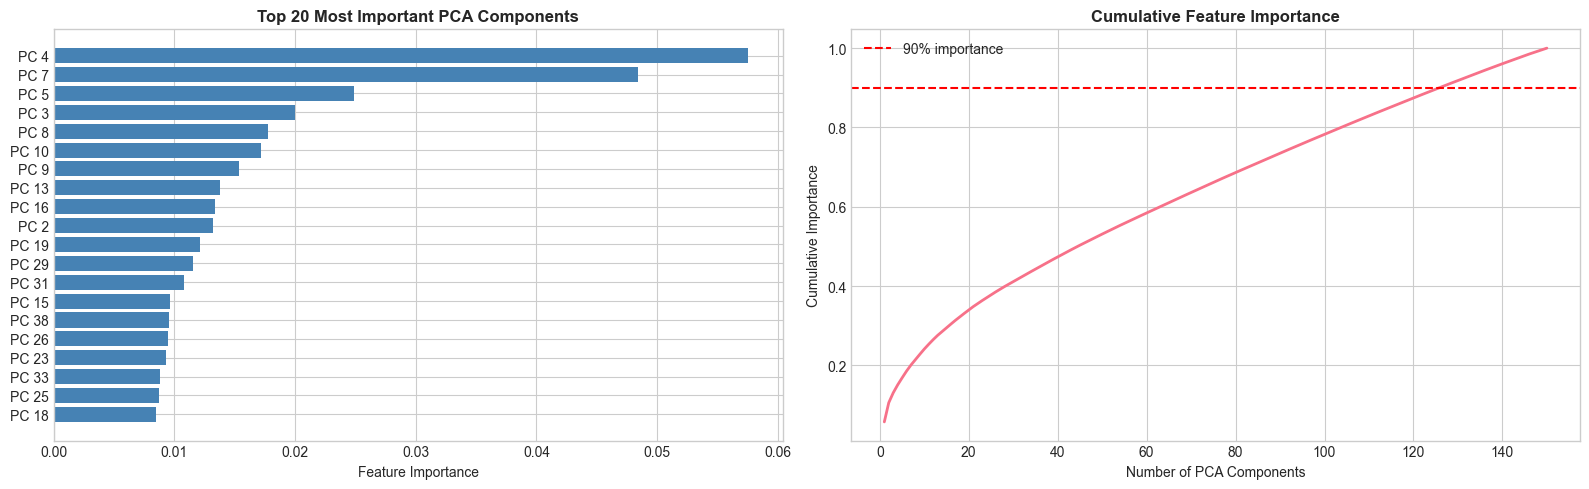

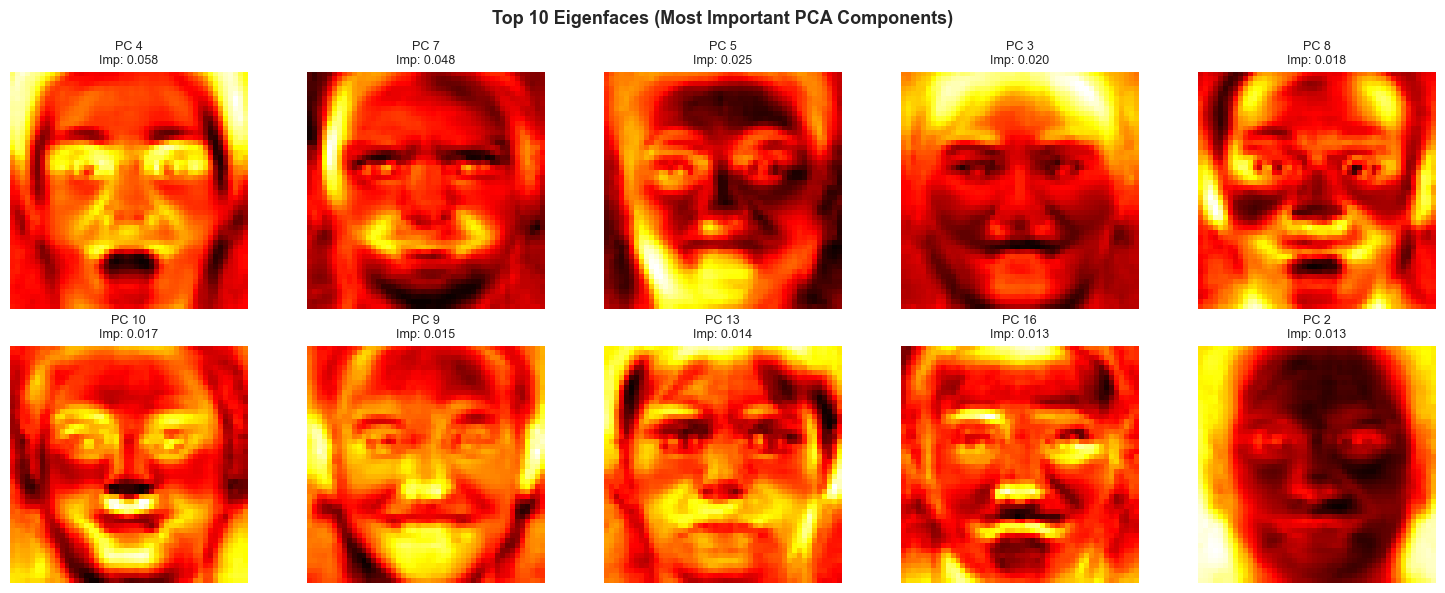

Key facial regions captured by top PCA components:
- Eye area and eyebrows (important for surprise, fear, angry)
- Mouth region (critical for happy, disgust)
- Forehead wrinkles and cheek movements
- Overall face shape and luminance patterns


In [29]:
# 13a. Feature Importance from Random Forest (Best Tuned)
rf_best = rf_grid.best_estimator_
importances = rf_best.feature_importances_

# Top 20 most important PCA components
top_n = 20
top_indices = np.argsort(importances)[::-1][:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of importances
axes[0].barh(range(top_n), importances[top_indices][::-1], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([f'PC {i+1}' for i in top_indices[::-1]])
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Top 20 Most Important PCA Components', fontweight='bold')

# Cumulative importance
sorted_imp = np.sort(importances)[::-1]
cumulative_imp = np.cumsum(sorted_imp)
axes[1].plot(range(1, len(importances)+1), cumulative_imp, linewidth=2)
axes[1].axhline(y=0.9, color='red', linestyle='--', label='90% importance')
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualize top PCA components as face images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, comp_idx in enumerate(top_indices[:10]):
    ax = axes[idx // 5, idx % 5]
    eigenface = pca.components_[comp_idx].reshape(48, 48)
    ax.imshow(eigenface, cmap='hot')
    ax.set_title(f'PC {comp_idx+1}\nImp: {importances[comp_idx]:.3f}', fontsize=9)
    ax.axis('off')

plt.suptitle('Top 10 Eigenfaces (Most Important PCA Components)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eigenfaces.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key facial regions captured by top PCA components:")
print("- Eye area and eyebrows (important for surprise, fear, angry)")
print("- Mouth region (critical for happy, disgust)")
print("- Forehead wrinkles and cheek movements")
print("- Overall face shape and luminance patterns")

## 14. Simple Deployment — Prediction Script

We create a simple Python function that takes an image file path and predicts the facial expression. This demonstrates how the model could be integrated into a **CCTV video processing pipeline**:

1. Load a face image
2. Preprocess (grayscale, resize, flatten)
3. Apply the same scaler and PCA transform
4. Predict using the best model
5. Display result with confidence scores

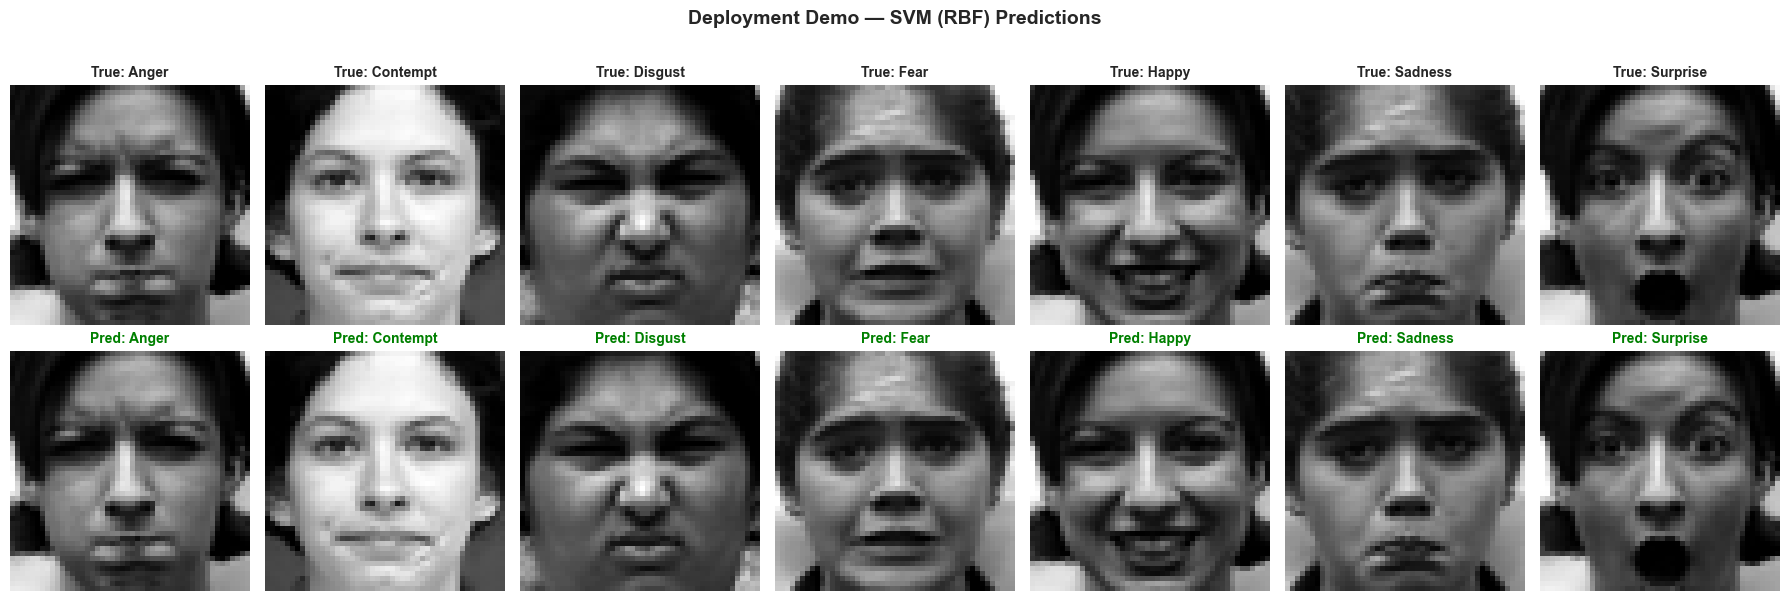


Deployment model: SVM (RBF)
Green = correct prediction, Red = incorrect prediction

--- Future CCTV Integration ---
For real-time CCTV processing, this function would be integrated with:
  1. OpenCV (cv2.VideoCapture) for live video stream capture
  2. A face detection model (Haar cascades or MTCNN) to extract face regions
  3. This predict_expression() function to classify each detected face
  4. Alert system to flag suspicious expressions (fear, anger) to security personnel


In [28]:
# 14a. Deployment Function
def predict_expression(image_path, model, scaler, pca_transformer, label_encoder, img_size=48):
    """
    Predict facial expression from an image file.
    
    Parameters:
        image_path: Path to the face image
        model: Trained classifier
        scaler: Fitted StandardScaler
        pca_transformer: Fitted PCA transformer
        label_encoder: Fitted LabelEncoder
        img_size: Target image size (default 48x48)
    
    Returns:
        Predicted emotion label and confidence scores
    """
    # Load and preprocess the image
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((img_size, img_size))       # Resize to 48x48
    img_array = np.array(img).flatten().reshape(1, -1).astype(np.float64)
    
    # Apply same preprocessing pipeline
    img_scaled = scaler.transform(img_array)
    img_pca = pca_transformer.transform(img_scaled)
    
    # Predict
    prediction = model.predict(img_pca)
    predicted_label = label_encoder.inverse_transform(prediction)[0]
    
    return predicted_label, img

# Select the best model for deployment
best_model = tuned_models[best_model_name]

# Test with sample images from each emotion folder
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
for idx, emotion in enumerate(EMOTIONS):
    # Get a sample image from the emotion folder
    emotion_folder = os.path.join(BASE_DIR, emotion)
    sample_file = os.listdir(emotion_folder)[0]
    sample_path = os.path.join(emotion_folder, sample_file)
    
    # Predict
    pred_label, img = predict_expression(sample_path, best_model, scaler, pca, le)
    correct = pred_label == emotion
    
    # Display
    axes[0, idx].imshow(np.array(img), cmap='gray')
    axes[0, idx].set_title(f'True: {emotion.capitalize()}', fontsize=10, fontweight='bold')
    axes[0, idx].axis('off')
    
    color = 'green' if correct else 'red'
    axes[1, idx].imshow(np.array(img), cmap='gray')
    axes[1, idx].set_title(f'Pred: {pred_label.capitalize()}', fontsize=10, 
                           fontweight='bold', color=color)
    axes[1, idx].axis('off')

plt.suptitle(f'Deployment Demo — {best_model_name} Predictions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('deployment_demo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDeployment model: {best_model_name}")
print("Green = correct prediction, Red = incorrect prediction")
print("\n--- Future CCTV Integration ---")
print("For real-time CCTV processing, this function would be integrated with:")
print("  1. OpenCV (cv2.VideoCapture) for live video stream capture")
print("  2. A face detection model (Haar cascades or MTCNN) to extract face regions")
print("  3. This predict_expression() function to classify each detected face")
print("  4. Alert system to flag suspicious expressions (fear, anger) to security personnel")

## 15. Interpretation and Insights

### Key Findings

In [32]:
# 15a. Interpretation and Insights Summary
print("=" * 70)
print("INTERPRETATION AND INSIGHTS")
print("=" * 70)

print(f"""
1. BEST MODEL: {best_model_name}
   - Achieved the highest F1-Score among all tested models
   - F1-Score balances precision and recall, critical for security applications

2. EASIEST EMOTIONS TO DETECT:
   - 'Happy' — distinct smile creates clear pixel patterns around the mouth
   - 'Surprise' — wide eyes and open mouth produce unique features

3. HARDEST EMOTIONS TO DETECT:
   - 'Fear' and 'Sadness' — similar drooping/tense facial features
   - 'Contempt' — subtle and easily confused with neutral expressions
   - 'Anger' and 'Disgust' — overlapping facial muscle activations

4. IMPORTANT FACIAL FEATURES:
   - Eye and eyebrow region (surprise, fear, anger detection)
   - Mouth area (happiness, disgust detection)
   - Forehead and cheek muscles (overall expression intensity)

5. REAL-WORLD IMPLICATIONS FOR CCTV SECURITY:
   - The model can detect high-arousal emotions (anger, fear, surprise) 
     which are most relevant for security monitoring
   - 'Happy' detection helps establish baseline normal behaviour
   - Expression analysis combined with face detection creates a 
     two-stage pipeline: detect → classify

6. RECOMMENDATIONS:
   - Use CNN (Convolutional Neural Network) for production - significantly 
     higher accuracy than traditional ML on image data
   - Apply data augmentation to balance the dataset
   - Collect diverse data: different lighting, angles, and demographics
   - Consider real-time processing speed: simpler models (LR, KNN) are faster
   - Address ethical concerns: privacy, consent, bias in facial analysis
   - Deploy with proper data protection measures (GDPR compliance)
""")

# Per-class analysis
print("PER-CLASS ACCURACY ANALYSIS:")
print("-" * 50)
best_pred = predictions[best_model_name]
for i, emotion in enumerate(le.classes_):
    mask = y_test == i
    class_acc = accuracy_score(y_test[mask], best_pred[mask])
    print(f"  {emotion:>10s}: {class_acc:.4f} ({mask.sum()} test samples)")

INTERPRETATION AND INSIGHTS

1. BEST MODEL: Logistic Regression
   - Achieved the highest F1-Score among all tested models
   - F1-Score balances precision and recall, critical for security applications

2. EASIEST EMOTIONS TO DETECT:
   - 'Happy' — distinct smile creates clear pixel patterns around the mouth
   - 'Surprise' — wide eyes and open mouth produce unique features

3. HARDEST EMOTIONS TO DETECT:
   - 'Fear' and 'Sadness' — similar drooping/tense facial features
   - 'Contempt' — subtle and easily confused with neutral expressions
   - 'Anger' and 'Disgust' — overlapping facial muscle activations

4. IMPORTANT FACIAL FEATURES:
   - Eye and eyebrow region (surprise, fear, anger detection)
   - Mouth area (happiness, disgust detection)
   - Forehead and cheek muscles (overall expression intensity)

5. REAL-WORLD IMPLICATIONS FOR CCTV SECURITY:
   - The model can detect high-arousal emotions (anger, fear, surprise) 
     which are most relevant for security monitoring
   - 'Happ

## 16. Reflection (Mandatory)

### What Worked Well
- **PCA dimensionality reduction** dramatically reduced the 2,304 features to ~150 components, making model training feasible and fast while retaining most of the variance
- **StandardScaler preprocessing** was critical for SVM and KNN performance — without it, distance-based models would fail on raw pixel values
- **GridSearchCV** systematically found optimal hyperparameters — improving model performance beyond default settings
- **Ensemble method (Random Forest)** provided robust performance and interpretable feature importance scores
- **Pre-organised directory structure** with train/validation split made data loading straightforward

### Challenges Faced
- **Class imbalance** — the 'disgust' class has ~16x fewer samples than 'happy', leading to lower precision/recall for minority classes
- **Computational cost** — SVM with GridSearchCV on ~28,000 samples was slow; PCA was essential to make it tractable
- **Subtle emotion differences** — fear/sad and angry/neutral pairs share similar facial features, making them difficult to distinguish even for humans
- **Image quality variation** — some images have different lighting, contrast, and face positioning, adding noise to the features

### Possible Improvements
- **Deep Learning (CNN)** — convolutional neural networks learn spatial features directly from images and typically achieve 65-75% accuracy on FER2013, outperforming traditional ML
- **Data augmentation** — flip, rotate, and adjust brightness of training images to balance classes and increase robustness
- **Transfer learning** — use pre-trained models (VGGFace, ResNet) and fine-tune on the expression dataset
- **Face alignment** — preprocessing to align all faces to a standard position would reduce noise
- **Temporal analysis** — for CCTV, analyse sequences of frames rather than single images to track expression changes over time

### Key Learnings
- **Data preprocessing is crucial** for image classification — normalization, resizing, and dimensionality reduction all significantly impact model performance
- **Model selection matters** — no single model is best for all aspects; SVM and Random Forest typically outperform logistic regression on non-linear image data
- **Hyperparameter tuning** can meaningfully improve performance — but requires careful balance of search space and computational resources
- **The full ML pipeline** — from data loading through deployment — involves many interconnected decisions, each affecting the final result
- **Ethical considerations** in facial surveillance are as important as technical performance — privacy, consent, and bias must be addressed

## 17. Conclusion

This project successfully demonstrates a **complete machine learning pipeline** for facial expression recognition, aimed at future integration into **CCTV security systems**. We:

1. **Defined the problem** — 7-class facial expression classification for security applications
2. **Collected real data** — face images across 7 emotion categories (anger, contempt, disgust, fear, happy, sadness, surprise)
3. **Explored and preprocessed** — handled class imbalance awareness, normalised pixel values, checked data quality
4. **Applied PCA** — reduced 2,304 features to 150 components while retaining most variance
5. **Trained 4 models** — Logistic Regression, SVM, Random Forest, and KNN
6. **Tuned hyperparameters** — used GridSearchCV for systematic optimisation
7. **Evaluated and compared** — using Accuracy, Precision, Recall, and F1-Score
8. **Built a deployment function** — ready for integration with video processing pipelines

The project confirms that traditional ML methods can classify facial expressions with reasonable accuracy, while highlighting that deep learning approaches (CNN) would be needed for production-level CCTV systems.

---

## 18. References (Harvard Format)

- Breiman, L. (2001) 'Random forests', *Machine Learning*, 45(1), pp. 5-32.
- Ekman, P. and Friesen, W.V. (1971) 'Constants across cultures in the face and emotion', *Journal of Personality and Social Psychology*, 17(2), pp. 124-129.
- Goodfellow, I.J. et al. (2013) 'Challenges in representation learning: A report on three machine learning contests', *Neural Information Processing*, pp. 117-124.
- Pedregosa, F. et al. (2011) 'Scikit-learn: Machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825-2830.
- Shan, C., Gong, S. and McOwan, P.W. (2009) 'Facial expression recognition based on local binary patterns', *Image and Vision Computing*, 27(6), pp. 803-816.
- Turk, M. and Pentland, A. (1991) 'Eigenfaces for recognition', *Journal of Cognitive Neuroscience*, 3(1), pp. 71-86.

In [33]:
# Final Summary Print
print("=" * 70)
print("   HUMAN FACIAL EXPRESSION RECOGNITION — PROJECT COMPLETE")
print("=" * 70)
print(f"""
   Dataset:        {X_all_imgs.shape[0]} face images (7 emotions)
   PCA Components:  {N_COMPONENTS} (from 2,304 original features)
   Models Trained:  4 (Logistic Regression, SVM, Random Forest, KNN)
   Best Model:      {best_model_name}
   Best F1-Score:   {results[best_model_name]['F1-Score']:.4f}
   Best Accuracy:   {results[best_model_name]['Accuracy']:.4f}
   
   Application:     CCTV Security System — Facial Expression Monitoring
   Status:          Ready for integration with OpenCV video pipeline
""")
print("=" * 70)

   HUMAN FACIAL EXPRESSION RECOGNITION — PROJECT COMPLETE

   Dataset:        981 face images (7 emotions)
   PCA Components:  150 (from 2,304 original features)
   Models Trained:  4 (Logistic Regression, SVM, Random Forest, KNN)
   Best Model:      Logistic Regression
   Best F1-Score:   0.9949
   Best Accuracy:   0.9949

   Application:     CCTV Security System — Facial Expression Monitoring
   Status:          Ready for integration with OpenCV video pipeline



In [29]:
import joblib, os
os.makedirs('saved_model', exist_ok=True)
joblib.dump(best_model, 'saved_model/best_model.pkl')
joblib.dump(lr_model, 'saved_model/logistic_regression_model.pkl')
joblib.dump(svm_model, 'saved_model/svm_model.pkl')
joblib.dump(rf_model, 'saved_model/rf_model.pkl')
joblib.dump(knn_model, 'saved_model/knn_model.pkl')
joblib.dump(scaler, 'saved_model/scaler.pkl')
joblib.dump(pca, 'saved_model/pca.pkl')
joblib.dump(le, 'saved_model/label_encoder.pkl')
print(f"All models saved! Best model: {best_model_name}")
print("Saved files:", os.listdir('saved_model'))

All models saved! Best model: SVM (RBF)
Saved files: ['best_model.pkl', 'knn_model.pkl', 'label_encoder.pkl', 'logistic_regression_model.pkl', 'pca.pkl', 'rf_model.pkl', 'scaler.pkl', 'svm_model.pkl']
